In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
import seaborn as sns



In [10]:
import mysql.connector

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)
cursor = conn.cursor()

In [11]:
cursor.execute("SELECT * FROM GameSales;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Name,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,31.37


In [12]:
sql_script = """
ALTER TABLE gamesales
DROP COLUMN IF EXISTS Rank,
DROP COLUMN IF EXISTS Other_Sales;

ALTER TABLE gamesales
CHANGE COLUMN Publisher `Company` VARCHAR(255),
CHANGE COLUMN NA_Sales `North America_Sales` DECIMAL(5,2),
CHANGE COLUMN EU_Sales `Europe_Sales` DECIMAL(5,2),
CHANGE COLUMN JP_Sales `Japan_Sales` DECIMAL(5,2);

CREATE TABLE gamesales_dedup AS
SELECT DISTINCT *
FROM gamesales;

DROP TABLE gamesales;
RENAME TABLE gamesales_dedup TO gamesales;

ALTER TABLE gamesales
MODIFY COLUMN Year FLOAT;

UPDATE gamesales
SET Year = 1909
WHERE Year IS NULL;

ALTER TABLE gamesales
MODIFY COLUMN Year INT;

UPDATE gamesales
SET Year = 1909
WHERE Year IS NULL;

ALTER TABLE gamesales
CHANGE COLUMN Platform Console VARCHAR(50);
"""

def run_sql_script(connection, script):
    cursor = connection.cursor()
    for statement in script.split(";"):
        stmt = statement.strip()
        if stmt:
            cursor.execute(stmt + ";")
    connection.commit()
    
    




In [13]:
cursor.execute("DESCRIBE gamesales;")
cursor.fetchall()

[('Name', 'text', 'YES', '', None, ''),
 ('Console', 'varchar(50)', 'YES', '', None, ''),
 ('Year', 'int', 'YES', '', None, ''),
 ('Genre', 'text', 'YES', '', None, ''),
 ('Company', 'varchar(255)', 'YES', '', None, ''),
 ('North America_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Europe_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Japan_Sales', 'decimal(5,2)', 'YES', '', None, ''),
 ('Global_Sales', 'double', 'YES', '', None, '')]

In [14]:
cursor.execute("SELECT * FROM gamesales LIMIT 20;")
cursor.fetchall()

[('Wii Sports',
  'Wii',
  2006,
  'Sports',
  'Nintendo',
  Decimal('41.49'),
  Decimal('29.02'),
  Decimal('3.77'),
  82.74),
 ('Super Mario Bros.',
  'NES',
  1985,
  'Platform',
  'Nintendo',
  Decimal('29.08'),
  Decimal('3.58'),
  Decimal('6.81'),
  40.24),
 ('Mario Kart Wii',
  'Wii',
  2008,
  'Racing',
  'Nintendo',
  Decimal('15.85'),
  Decimal('12.88'),
  Decimal('3.79'),
  35.82),
 ('Wii Sports Resort',
  'Wii',
  2009,
  'Sports',
  'Nintendo',
  Decimal('15.75'),
  Decimal('11.01'),
  Decimal('3.28'),
  33.0),
 ('Pokemon Red/Pokemon Blue',
  'GB',
  1996,
  'Role-Playing',
  'Nintendo',
  Decimal('11.27'),
  Decimal('8.89'),
  Decimal('10.22'),
  31.37),
 ('Tetris',
  'GB',
  1989,
  'Puzzle',
  'Nintendo',
  Decimal('23.20'),
  Decimal('2.26'),
  Decimal('4.22'),
  30.26),
 ('New Super Mario Bros.',
  'DS',
  2006,
  'Platform',
  'Nintendo',
  Decimal('11.38'),
  Decimal('9.23'),
  Decimal('6.50'),
  30.01),
 ('Wii Play',
  'Wii',
  2006,
  'Misc',
  'Nintendo',
  Decim

In [15]:
import pandas as pd

cursor.execute("SELECT * FROM gamesales ORDER BY Genre DESC;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Name,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Worms 2,PC,1997,Strategy,Microprose,0.00,0.01,0.00,0.01
1,Total War Attila: Tyrants & Kings,PC,2016,Strategy,Koch Media,0.00,0.01,0.00,0.01
2,Ishin no Arashi: Shippuu Ryuumeden,DS,2010,Strategy,Tecmo Koei,0.00,0.00,0.01,0.01
3,Hospital Tycoon,PC,2007,Strategy,Codemasters,0.00,0.01,0.00,0.01
4,Shutsugeki! Otometachi no Senjou 2: Ikusabana ...,PSP,2011,Strategy,System Soft,0.00,0.00,0.01,0.01


In [ ]:
df_vgsales = pd.read_csv('C:\\Users\\Tonika Price\\Source\\Repos\\EvolutionOfGaming\\Data\\GameSales.csv')
df_vgsales.head(20)


In [ ]:
list(df_vgsales.columns)
df_vgsales.columns

In [ ]:
remove_columns = ['Rank', 'Other_Sales',]

df_vgsales.drop(columns=remove_columns, inplace=True)
df_vgsales.head()


In [ ]:
change_columns = {
    'Name': 'Game',
    'Publisher': 'Company',
    'NA_Sales': 'North America_Sales',
    'EU_Sales': 'Europe_Sales',
    'JP_Sales': 'Japan_Sales',}
df_vgsales.rename(columns=change_columns, inplace=True)
df_vgsales.head()


    

In [48]:
df_vgsales.isna()  
df_vgsales.isna().sum()

Game                     0
Platform                 0
Year                   271
Genre                    0
Company                 58
North America_Sales      0
Europe_Sales             0
Japan_Sales              0
Global_Sales             0
dtype: int64

In [49]:
df_vgsales.loc[df_vgsales['Company'].isna()]

,Game,Platform,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
470,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,3.00
1303,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,1.46
1662,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.00,1.21
2222,Bentley's Hackpack,GBA,2005.0,Misc,NaN,0.67,0.25,0.00,0.93
3159,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.64
3166,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.64
3766,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.38,0.14,0.00,0.53
4145,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.48
4526,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.31,0.11,0.00,0.43
4635,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.30,0.11,0.00,0.42


In [50]:
df_vgsales.duplicated(keep=False).sum()# check for duplicates

np.int64(2)

In [51]:
df_vgsales.loc[df_vgsales['Platform'].duplicated(keep=False)].sort_values('Platform')

,Game,Platform,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
8757,Klax,2600,1989.0,Puzzle,Atari,0.14,0.01,0.00,0.15
4139,Grand Prix,2600,1981.0,Racing,Activision,0.45,0.03,0.00,0.48
4469,Super Breakout,2600,NaN,Puzzle,Atari,0.41,0.03,0.00,0.44
3716,Action Force,2600,1982.0,Action,CPG Products,0.50,0.03,0.00,0.54
5798,Slot Machine,2600,NaN,Action,Atari,0.29,0.02,0.00,0.31
...,...,...,...,...,...,...,...,...,...
193,Call of Duty: Advanced Warfare,XOne,2014.0,Shooter,Activision,3.21,1.53,0.01,5.13
15153,Rugby World Cup 2015,XOne,2015.0,Sports,Ubisoft,0.00,0.02,0.00,0.02
14186,Teenage Mutant Ninja Turtles: Mutants in Manha...,XOne,2016.0,Action,Activision,0.02,0.01,0.00,0.03
3359,Tomb Raider (2013),XOne,2014.0,Action,Square Enix,0.34,0.21,0.00,0.60


In [52]:
df_vgsales.dtypes# check data types of columns

Game                       str
Platform                   str
Year                   float64
Genre                      str
Company                    str
North America_Sales    float64
Europe_Sales           float64
Japan_Sales            float64
Global_Sales           float64
dtype: object

In [54]:
df_vgsales = df_vgsales.astype({'Year':'float64'}) # convert Year column to float64

df_vgsales['Year'] = df_vgsales['Year'].fillna('1909') # fill missing values in Year column with 1909, the year of the first video game release

In [55]:
df_vgsales.head(20)

,Game,Platform,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,31.37
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,30.26
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,30.01
7,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,29.02
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,28.62
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,28.31


In [56]:
df_vgsales = df_vgsales.astype({'Year':'int64'}) # convert Year column to int64 after filling missing values with 1909

df_vgsales['Year'] = df_vgsales['Year'].fillna(1909) # fill any remaining missing values in Year column with 1909

df_vgsales.head()

,Game,Platform,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,31.37


In [57]:
change_columns = {
    'Platform': 'Console',}# Rename Platform column to Console for consistency with GameConsoles table
df_vgsales.rename(columns=change_columns, inplace=True)
df_vgsales.head()


,Game,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,31.37


In [58]:
sorted_df_vgsales = df_vgsales.sort_values(by=['Genre'], ascending=False) # sort by Genre column in descending order to get the most popular genres at the top
Top_10_Genre = sorted_df_vgsales.head(10)
Top_10_Genre

,Game,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
11820,Kessen III,PS2,2004,Strategy,Tecmo Koei,0.04,0.03,0.00,0.07
806,Warcraft: Orcs & Humans,PC,1994,Strategy,Activision,0.89,1.08,0.00,2.08
2133,Fire Emblem,GBA,2003,Strategy,Nintendo,0.49,0.18,0.29,0.97
11703,Tears to Tiara: Garland of the Earth,PS3,2008,Strategy,Aqua Plus,0.00,0.00,0.08,0.08
11699,P.T.O. IV: Pacific Theater of Operations,PS2,2002,Strategy,Tecmo Koei,0.04,0.03,0.00,0.08
11692,Stella Deus: The Gate of Eternity,PS2,2004,Strategy,505 Games,0.04,0.03,0.00,0.08
11678,The Lord of the Rings: The Battle for Middle-E...,PC,2004,Strategy,Electronic Arts,0.01,0.06,0.00,0.08
11677,Quo Vadis,SAT,1995,Strategy,Glams,0.00,0.00,0.08,0.08
11671,Dragon Force II: Kamisarishi Daichi ni,SAT,1998,Strategy,Sega,0.00,0.00,0.08,0.08
4992,SD Gundam G Generation Spirits,PS2,2007,Strategy,Namco Bandai Games,0.00,0.00,0.38,0.38


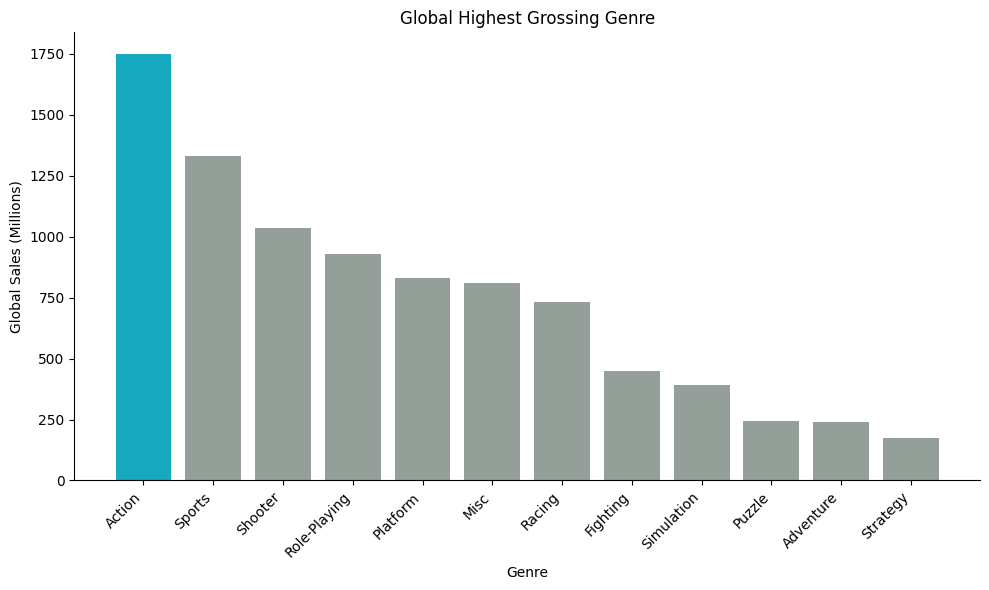

In [59]:
Genre= df_vgsales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False) # Group by Genre and sum Global_Sales, then sort in descending order
plt.figure(figsize=(10, 6)) # Set the figure size for better visibility
colors = ["#959f99"]*len(Genre)# Create a list of colors for the bars

max_index = Genre.idxmax() # Get the index of the maximum value in the Genre series
highlight_position = Genre.index.get_loc(max_index)# Get the position of the maximum value in the Genre series
colors[highlight_position] = "#17a9bf" # Change the color of the bar with the maximum value to a different color (e.g., "#17a9bf")

plt.bar(Genre.index, Genre.values, color = colors, width = 0.8) # Create a bar chart with the specified colors and width
ax = plt.gca() # Get the current axes object
ax.spines['top'].set_visible(False) # Remove the top spine
ax.spines['right'].set_visible(False) # Remove the right spine


plt.xlabel("Genre")# Add a label for the x-axis
plt.ylabel("Global Sales (Millions)")# Add a label for the y-axis
plt.title("Global Highest Grossing Genre")# Add a title to the chart
plt.xticks(rotation=45, ha="right")# Rotate x-axis labels for better readability

plt.tight_layout() # Adjust layout to prevent clipping of tick-labels
plt.show()

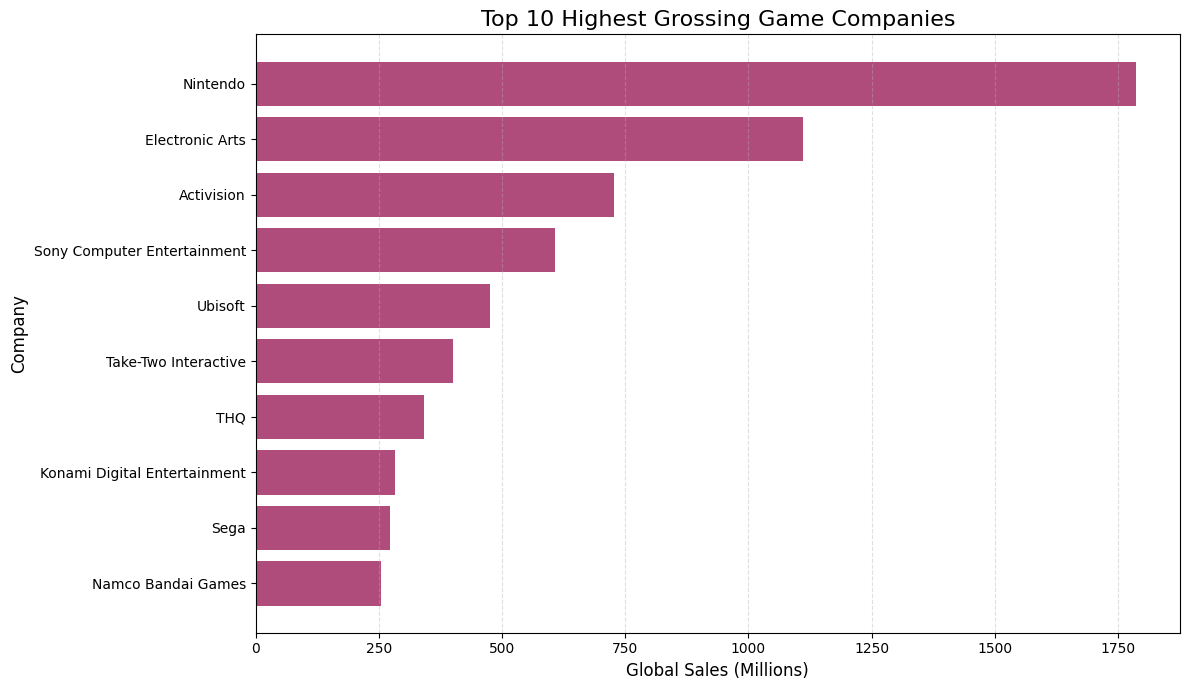

In [77]:
Company_sales = (
    df_vgsales.groupby("Company")["Global_Sales"]#  Group by Company and sum Global_Sales
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))# Set the figure size for better visibility

# Horizontal bar chart
plt.barh(
    Company_sales["Company"],
    Company_sales["Global_Sales"],
    color="#B04C7B"
)

plt.title("Top 10 Highest Grossing Game Companies", fontsize=16)# Add a title to the chart#
plt.xlabel("Global Sales (Millions)", fontsize=12)
plt.ylabel("Company", fontsize=12)

# Highest value at the top
plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

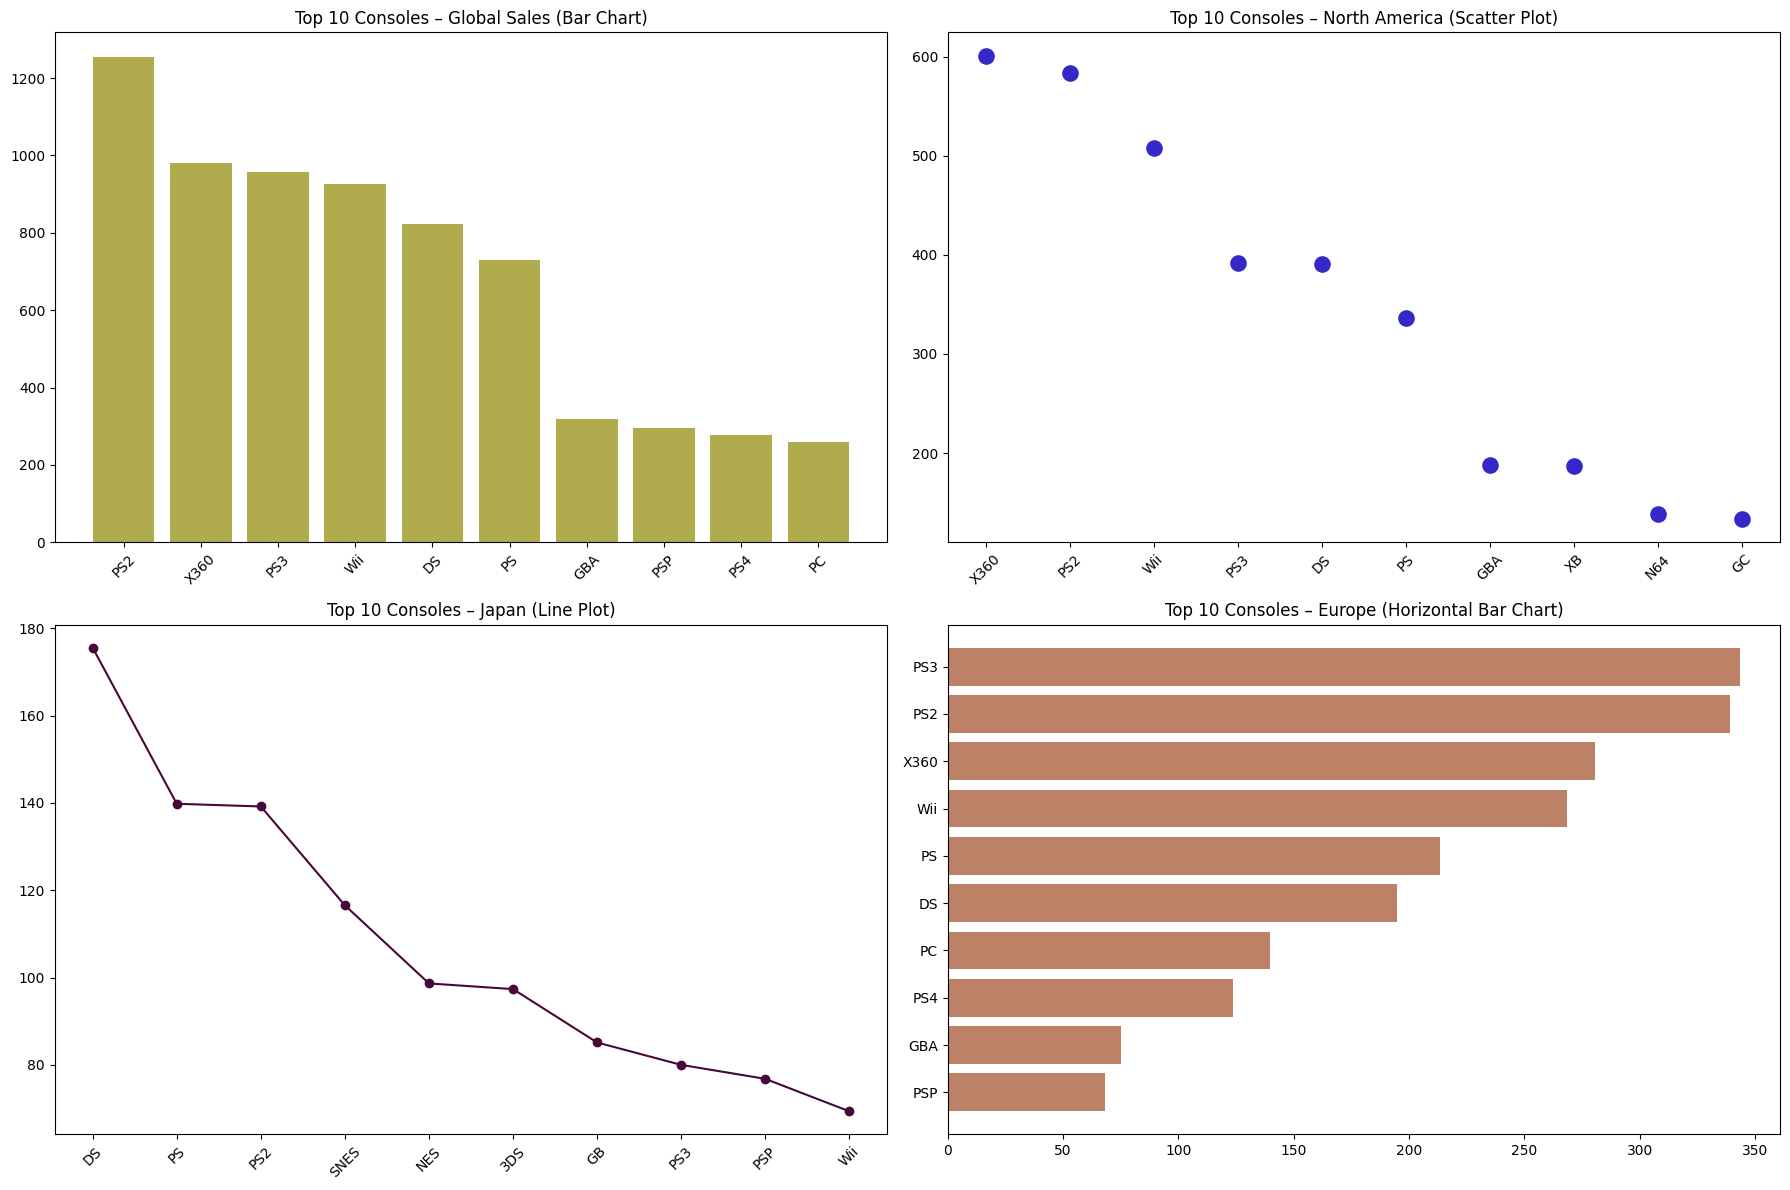

In [63]:


# Create top 10 for each region
global_sales = (
    df_vgsales.groupby("Console")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

na_sales = (
    df_vgsales.groupby("Console")["North America_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

jp_sales = (
    df_vgsales.groupby("Console")["Japan_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

eu_sales = (
    df_vgsales.groupby("Console")["Europe_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- 1. Global: Bar Chart ---
axes[0, 0].bar(global_sales["Console"], global_sales["Global_Sales"], color="#B0AB4C")
axes[0, 0].set_title("Top 10 Consoles – Global Sales (Bar Chart)")
axes[0, 0].tick_params(axis="x", rotation=45)

# --- 2. North America: Scatter Plot ---
axes[0, 1].scatter(na_sales["Console"], na_sales["North America_Sales"], color="#3528C9", s=120)
axes[0, 1].set_title("Top 10 Consoles – North America (Scatter Plot)")
axes[0, 1].tick_params(axis="x", rotation=45)

# --- 3. Japan: Line Plot ---
axes[1, 0].plot(jp_sales["Console"], jp_sales["Japan_Sales"], marker="o", color="#470738")
axes[1, 0].set_title("Top 10 Consoles – Japan (Line Plot)")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- 4. Europe: Horizontal Bar Chart ---
axes[1, 1].barh(eu_sales["Console"], eu_sales["Europe_Sales"], color="#BD8167")
axes[1, 1].set_title("Top 10 Consoles – Europe (Horizontal Bar Chart)")
axes[1, 1].invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()

In [64]:
sorted_df_vgsales = df_vgsales.sort_values(by=['Console'], ascending=False) 
Console = sorted_df_vgsales.head(20)
Console

,Game,Console,Year,Genre,Company,North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
15052,NASCAR Heat Evolution,XOne,2016,Racing,Dusenberry Martin Racing,0.02,0.00,0.00,0.02
12071,Divinity: Original Sin,XOne,2015,Role-Playing,Focus Home Interactive,0.04,0.02,0.00,0.07
15612,The Crew: Wild Run,XOne,2015,Action,Ubisoft,0.00,0.02,0.00,0.02
2972,Plants vs. Zombies: Garden Warfare,XOne,2014,Shooter,Electronic Arts,0.39,0.23,0.00,0.68
12117,Just Dance: Disney Party 2,XOne,2015,Action,Ubisoft,0.05,0.01,0.00,0.07
5762,Disney Infinity 3.0,XOne,2015,Action,Disney Interactive Studios,0.18,0.10,0.00,0.31
193,Call of Duty: Advanced Warfare,XOne,2014,Shooter,Activision,3.21,1.53,0.01,5.13
2554,Dying Light,XOne,2015,Action,Warner Bros. Interactive Entertainment,0.43,0.30,0.01,0.81
197,Grand Theft Auto V,XOne,2014,Action,Take-Two Interactive,2.66,2.01,0.00,5.08
467,Gears of War: Ultimate Edition,XOne,2015,Shooter,Microsoft Game Studios,2.38,0.32,0.00,3.00


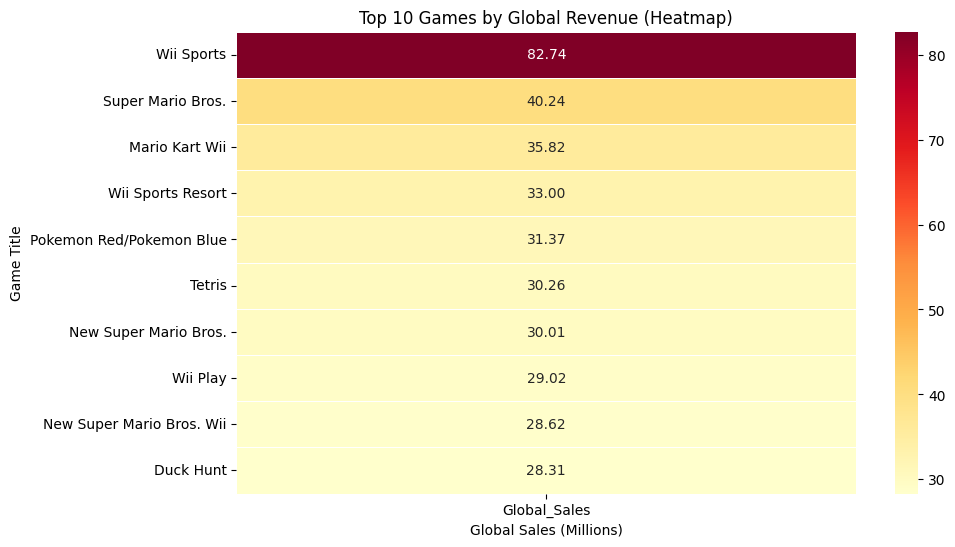

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort and select top 10 games by Global Sales
sorted_df_vgsales = df_vgsales.sort_values(by=['Global_Sales'], ascending=False)
Global_Sales = sorted_df_vgsales.head(10)

# Set the Game column as the index so it appears on the y-axis
Global_Sales = Global_Sales.set_index("Game")

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    Global_Sales[['Global_Sales']],
    annot=True,
    cmap='YlOrRd',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Top 10 Games by Global Revenue (Heatmap)")
plt.ylabel("Game Title")
plt.xlabel("Global Sales (Millions)")
plt.show()

In [66]:
#Which country has made the most revenue in video gaming between Japan, North America, and Europe?

# Sum total sales by region
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sum total sales by region
na_sales = df_vgsales["North America_Sales"].sum()
eu_sales = df_vgsales["Europe_Sales"].sum()
jp_sales = df_vgsales["Japan_Sales"].sum()

# Create summary DataFrame
region_sales = pd.DataFrame({
    "Region": ["North America", "Europe", "Japan"],
    "Total Sales (Millions)": [na_sales, eu_sales, jp_sales]
})

# Sort by revenue
region_sales = region_sales.sort_values(
    by="Total Sales (Millions)",
    ascending=False
)

# Display result
print(region_sales)



          Region  Total Sales (Millions)
0  North America                 4392.95
1         Europe                 2434.13
2          Japan                 1291.02


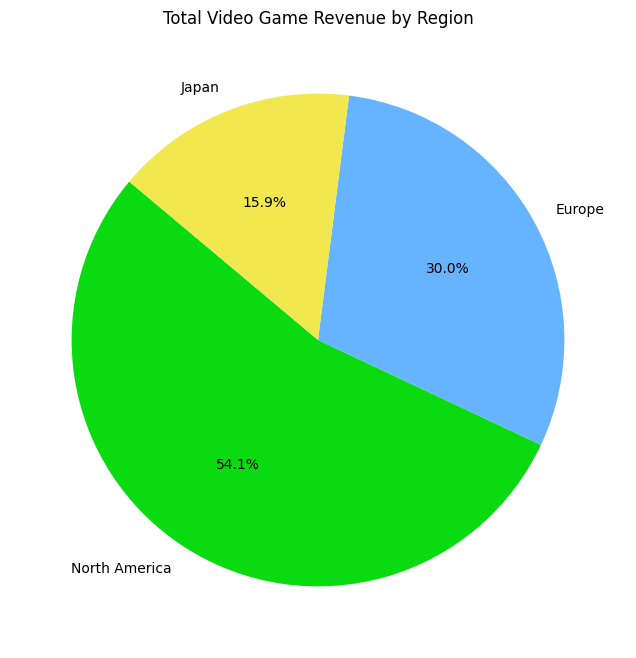

In [67]:
# Sum total sales by region
na_sales = df_vgsales["North America_Sales"].sum()
eu_sales = df_vgsales["Europe_Sales"].sum()
jp_sales = df_vgsales["Japan_Sales"].sum()

# Labels and values
regions = ["North America", "Europe", "Japan"]
sales = [na_sales, eu_sales, jp_sales]

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sales,
    labels=regions,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#0adb11", "#66b3ff", "#f0e84e"]
)

plt.title("Total Video Game Revenue by Region")
plt.show()

In [69]:
# list(df_vgsales.columns)
df_vgsales.columns

Index(['Game', 'Console', 'Year', 'Genre', 'Company', 'North America_Sales',
       'Europe_Sales', 'Japan_Sales', 'Global_Sales'],
      dtype='str')